# 04 — City Comparison & Solar Suitability Ranking
**Project:** Climate-Driven Solar Energy Analytics  
**Goal:** Compare all 15 Indian cities and produce a ranked suitability score for solar farm installation.

---
### Why compare cities?
Solar potential varies enormously across India — a city in Rajasthan gets far more radiation
than one on the Kerala coast. Identifying which cities are **consistently good** (not just
occasionally great) is the core deliverable of our recommender system.

### What we build here
1. **Fix the loading bug** — `download_log.csv` has no 17-row header; the loop was trying to skip rows on it → `EmptyDataError`.
2. **Compare** mean solar radiation, cloud cover, humidity, and rainfall across all cities.
3. **Compute a composite suitability score** — a weighted combination of factors.
4. **Produce the final ranked recommendation** table.

In [1]:
# ── Imports & config ──────────────────────────────────────────────────────
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RAW_DIR = "../data/raw"
TARGET  = "ALLSKY_SFC_SW_DWN"

# Only city-level CSV files; exclude logs and other auxiliary files
CITY_NAMES = [
    "Ahmedabad", "Bengaluru", "Bhopal", "Bhubaneswar", "Chandigarh",
    "Chennai", "Delhi", "Guwahati", "Hyderabad", "Jaipur",
    "Kochi", "Kolkata", "Mangalore", "Mumbai", "Pune"
]

---
## 1 · Load All Cities  *(Bug Fixed)*

**Root cause of the original error:**  
The code used `os.listdir()` which returns *all* `.csv` files — including `download_log.csv`.
That file has no 17-line NASA header. Calling `skiprows=17` on it skipped all its data,
leaving an empty frame → `EmptyDataError: No columns to parse from file`.

**Fix:** Explicitly list only the known city names instead of scanning the directory blindly.

In [2]:
city_frames = []
load_errors = []

for city in CITY_NAMES:
    path = os.path.join(RAW_DIR, f"{city}.csv")
    try:
        df_city = pd.read_csv(path, skiprows=17)
        df_city["CITY"] = city
        df_city["DATE"] = pd.to_datetime({
            "year":  df_city["YEAR"],
            "month": df_city["MO"],
            "day":   df_city["DY"]
        })
        city_frames.append(df_city)
    except FileNotFoundError:
        load_errors.append(f"⚠️  {city}: file not found")
    except Exception as e:
        load_errors.append(f"❌  {city}: {e}")

if load_errors:
    print("Load issues:")
    for err in load_errors:
        print(" ", err)

all_data = pd.concat(city_frames, ignore_index=True)

print(f"✅ Loaded {len(city_frames)} cities")
print(f"Total rows : {all_data.shape[0]:,}")
print(f"Columns    : {all_data.shape[1]}")
print(f"Cities     : {all_data['CITY'].nunique()}")
print()
print(all_data.groupby("CITY").size().rename("rows").to_frame().T)

✅ Loaded 15 cities
Total rows : 32,880
Columns    : 14
Cities     : 15

CITY  Ahmedabad  Bengaluru  Bhopal  Bhubaneswar  Chandigarh  Chennai  Delhi  \
rows       2192       2192    2192         2192        2192     2192   2192   

CITY  Guwahati  Hyderabad  Jaipur  Kochi  Kolkata  Mangalore  Mumbai  Pune  
rows      2192       2192    2192   2192     2192       2192    2192  2192  


---
## 2 · City-Level Summary Statistics
For each city we compute the **annual mean** of the five variables most relevant to suitability:
solar radiation (maximise), cloud amount, humidity, rainfall (all minimise).

We also compute **consistency** as 1 − coefficient of variation (CV). A city with high average
solar radiation but very high variance is less dependable for a solar farm than one
with slightly lower but more consistent output.

In [3]:
city_summary = all_data.groupby("CITY").agg(
    Solar_Mean    = (TARGET,       "mean"),
    Solar_Std     = (TARGET,       "std"),
    Cloud_Mean    = ("CLOUD_AMT",  "mean"),
    Humidity_Mean = ("RH2M",       "mean"),
    Rainfall_Mean = ("PRECTOTCORR","mean"),
    Temp_Mean     = ("T2M_MAX",    "mean"),
).round(3)

# Consistency = 1 − (Std / Mean); higher = more stable output
city_summary["Solar_Consistency"] = (
    1 - (city_summary["Solar_Std"] / city_summary["Solar_Mean"])
).round(3)

city_summary = city_summary.sort_values("Solar_Mean", ascending=False)

print(city_summary[["Solar_Mean", "Solar_Consistency", "Cloud_Mean",
                     "Humidity_Mean", "Rainfall_Mean"]].to_string())

             Solar_Mean  Solar_Consistency  Cloud_Mean  Humidity_Mean  Rainfall_Mean
CITY                                                                                
Ahmedabad         5.285              0.732      44.897         54.053          2.449
Bengaluru         5.272              0.763      62.417         70.196          2.865
Kochi             5.267              0.762      62.100         78.827          7.743
Mangalore         5.135              0.728      61.367         77.378         10.892
Jaipur            5.115              0.722      56.266         49.425          2.191
Mumbai            5.076              0.710      49.180         69.691          8.355
Chennai           5.066              0.730      54.058         74.850          4.162
Chandigarh        5.063              0.660      45.147         56.220          3.561
Hyderabad         5.033              0.751      53.496         65.108          2.666
Bhopal            4.965              0.692      45.174         58

---
## 3 · Visual Comparison — Solar Radiation by City

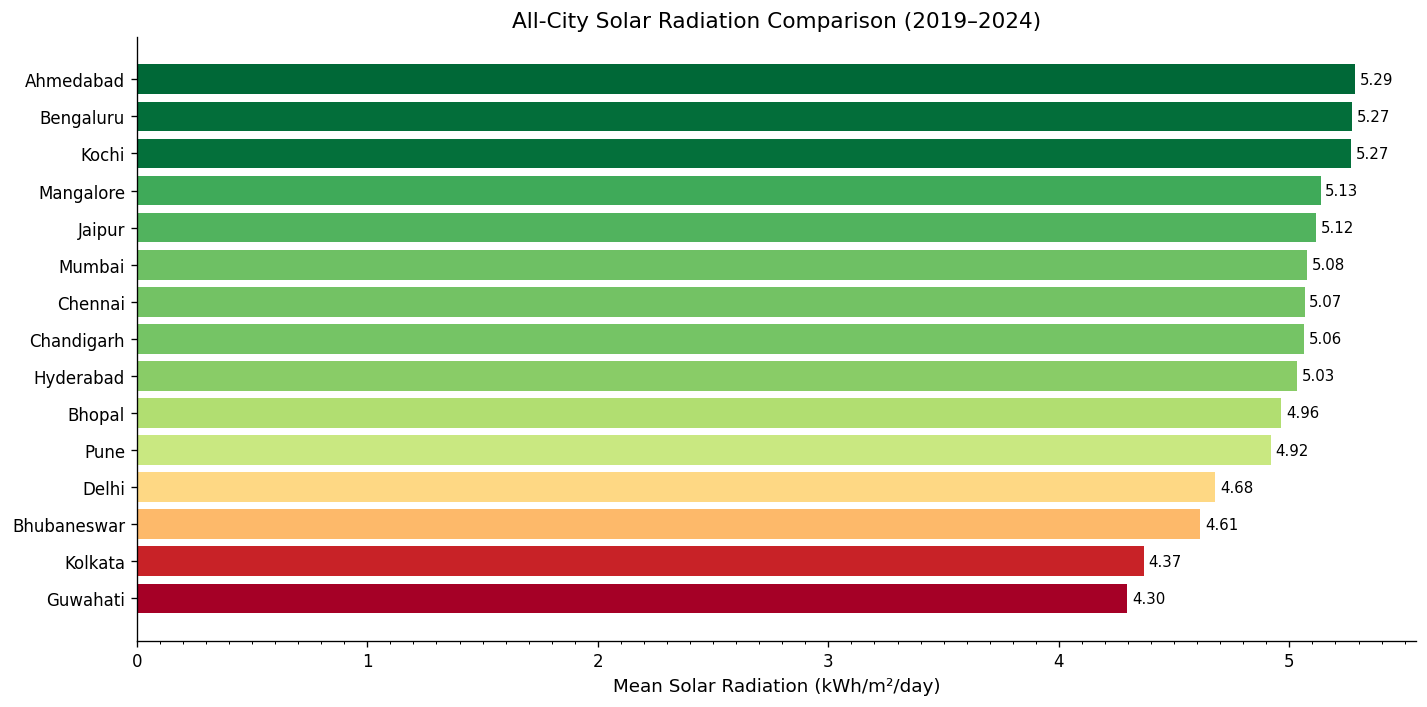

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

cities_sorted = city_summary.index.tolist()  # already sorted by Solar_Mean
values        = city_summary["Solar_Mean"]

# Colour gradient: top cities → dark orange, bottom → pale blue
norm   = plt.Normalize(values.min(), values.max())
colors = plt.cm.RdYlGn(norm(values))

bars = ax.barh(cities_sorted[::-1], values.iloc[::-1], color=colors[::-1], edgecolor="none")

for bar, val in zip(bars, values.iloc[::-1]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)

ax.set_xlabel("Mean Solar Radiation (kWh/m²/day)")
ax.set_title("All-City Solar Radiation Comparison (2019–2024)")
ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.1))
plt.tight_layout()
plt.show()

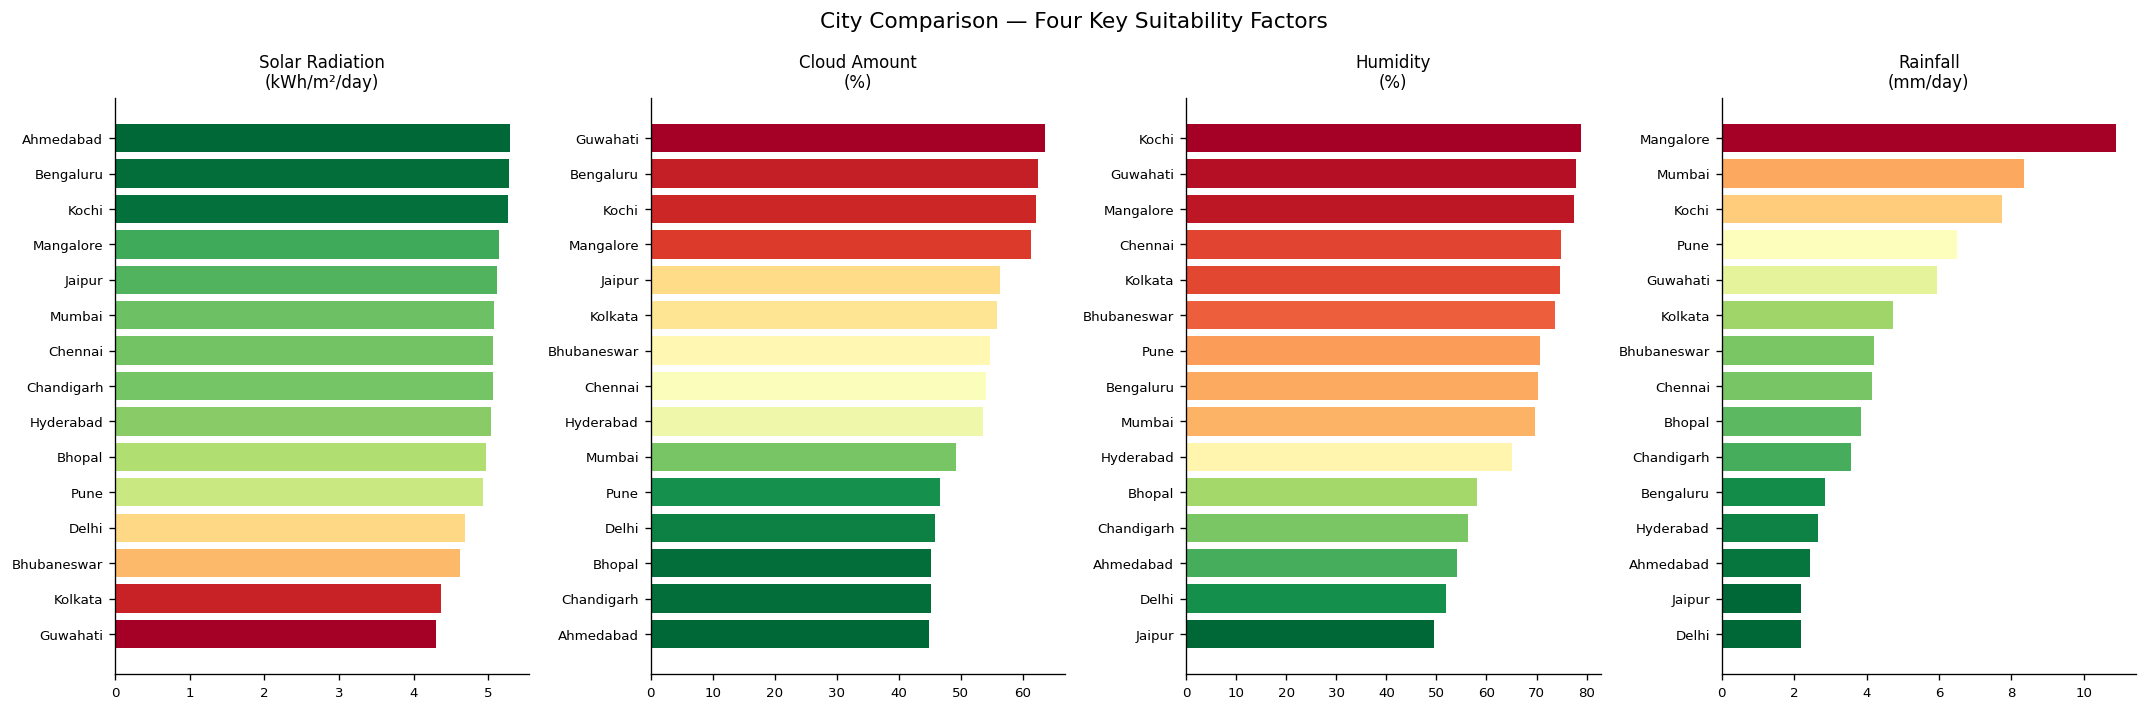

In [5]:
# ── Side-by-side comparison: 4 key factors ────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

metrics = [
    ("Solar_Mean",     "Solar Radiation\n(kWh/m²/day)",  "RdYlGn",  True),
    ("Cloud_Mean",     "Cloud Amount\n(%)",               "RdYlGn_r",True),
    ("Humidity_Mean",  "Humidity\n(%)",                   "RdYlGn_r",True),
    ("Rainfall_Mean",  "Rainfall\n(mm/day)",              "RdYlGn_r",True),
]

for ax, (col, label, cmap, sort_asc) in zip(axes, metrics):
    sorted_df = city_summary[col].sort_values(ascending=not sort_asc)
    norm   = plt.Normalize(sorted_df.min(), sorted_df.max())
    colors = getattr(plt.cm, cmap)(norm(sorted_df.values))

    ax.barh(sorted_df.index[::-1], sorted_df.values[::-1],
            color=colors[::-1], edgecolor="none")
    ax.set_title(label, fontsize=10)
    ax.tick_params(labelsize=8)

fig.suptitle("City Comparison — Four Key Suitability Factors", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4 · Composite Suitability Score

We compute a **weighted composite score** by:
1. **Min-max normalising** each factor to 0–1 so they're on the same scale.
2. **Inverting** factors where *lower is better* (cloud, humidity, rainfall).
3. **Multiplying by weights** that reflect each factor's relative importance.

### Weight rationale
| Factor | Weight | Reasoning |
|--------|--------|----------|
| Solar Radiation | 40 % | The most direct measure of energy potential |
| Cloud Cover | 25 % | Strongest single climate barrier to solar |
| Humidity | 20 % | Causes haze and diffuse radiation loss |
| Rainfall | 10 % | Indirect; very rainy = cloudy, already captured |
| Consistency | 5 % | Stable supply is valuable for grid planning |

> **Note:** These weights are a starting point. In Phase 8 you can make them configurable
> so stakeholders can adjust priorities (e.g. weight consistency higher for off-grid installs).

In [6]:
def minmax(series, invert=False):
    """Normalise a series to 0-1. Invert=True when lower raw value = better."""
    lo, hi = series.min(), series.max()
    normalised = (series - lo) / (hi - lo)
    return (1 - normalised) if invert else normalised

WEIGHTS = {
    "Solar_Mean"        : 0.40,
    "Cloud_Mean"        : 0.25,
    "Humidity_Mean"     : 0.20,
    "Rainfall_Mean"     : 0.10,
    "Solar_Consistency" : 0.05,
}
INVERT = {"Cloud_Mean": True, "Humidity_Mean": True, "Rainfall_Mean": True}

scoring = city_summary.copy()
score = pd.Series(0.0, index=scoring.index)

for col, weight in WEIGHTS.items():
    normalised = minmax(scoring[col], invert=INVERT.get(col, False))
    score += weight * normalised
    scoring[f"{col}_norm"] = normalised.round(3)

scoring["Suitability_Score"] = (score * 100).round(2)  # out of 100
ranking = scoring.sort_values("Suitability_Score", ascending=False).reset_index()
ranking.index += 1  # rank starts at 1
ranking.index.name = "Rank"

print(ranking[["CITY", "Solar_Mean", "Cloud_Mean", "Humidity_Mean",
               "Rainfall_Mean", "Solar_Consistency", "Suitability_Score"]].to_string())

             CITY  Solar_Mean  Cloud_Mean  Humidity_Mean  Rainfall_Mean  Solar_Consistency  Suitability_Score
Rank                                                                                                         
1       Ahmedabad       5.285      44.897         54.053          2.449              0.732              95.09
2      Chandigarh       5.063      45.147         56.220          3.561              0.660              79.62
3          Jaipur       5.115      56.266         49.425          2.191              0.722              75.98
4          Bhopal       4.965      45.174         58.198          3.849              0.692              75.45
5           Delhi       4.679      45.883         51.900          2.190              0.657              67.46
6       Hyderabad       5.033      53.496         65.108          2.666              0.751              66.52
7          Mumbai       5.076      49.180         69.691          8.355              0.710              62.44
8       Be

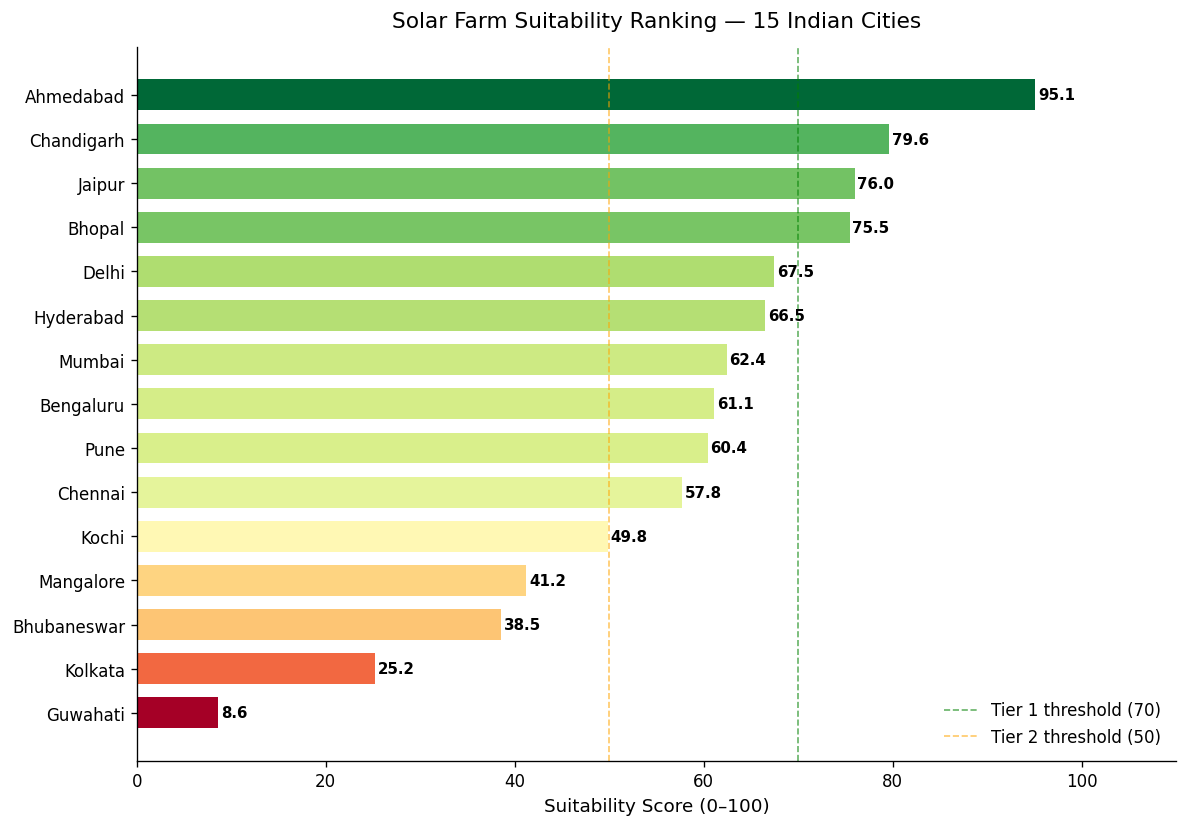

In [7]:
# ── Ranking visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

scores = ranking.set_index("CITY")["Suitability_Score"]
norm   = plt.Normalize(scores.min(), scores.max())
colors = plt.cm.RdYlGn(norm(scores.values))

bars = ax.barh(scores.index[::-1], scores.values[::-1],
               color=colors[::-1], edgecolor="none", height=0.7)

for bar, val in zip(bars, scores.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Suitability Score (0–100)")
ax.set_title("Solar Farm Suitability Ranking — 15 Indian Cities", pad=12)
ax.set_xlim(0, 110)

# Tier lines
ax.axvline(70, color="green",  linestyle="--", linewidth=1, alpha=0.6, label="Tier 1 threshold (70)")
ax.axvline(50, color="orange", linestyle="--", linewidth=1, alpha=0.6, label="Tier 2 threshold (50)")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

---
## 5 · Seasonal Profiles — All Cities
Even if two cities have similar annual averages, their seasonal patterns may differ significantly.
A heatmap of monthly solar radiation across all cities makes this immediately visible.

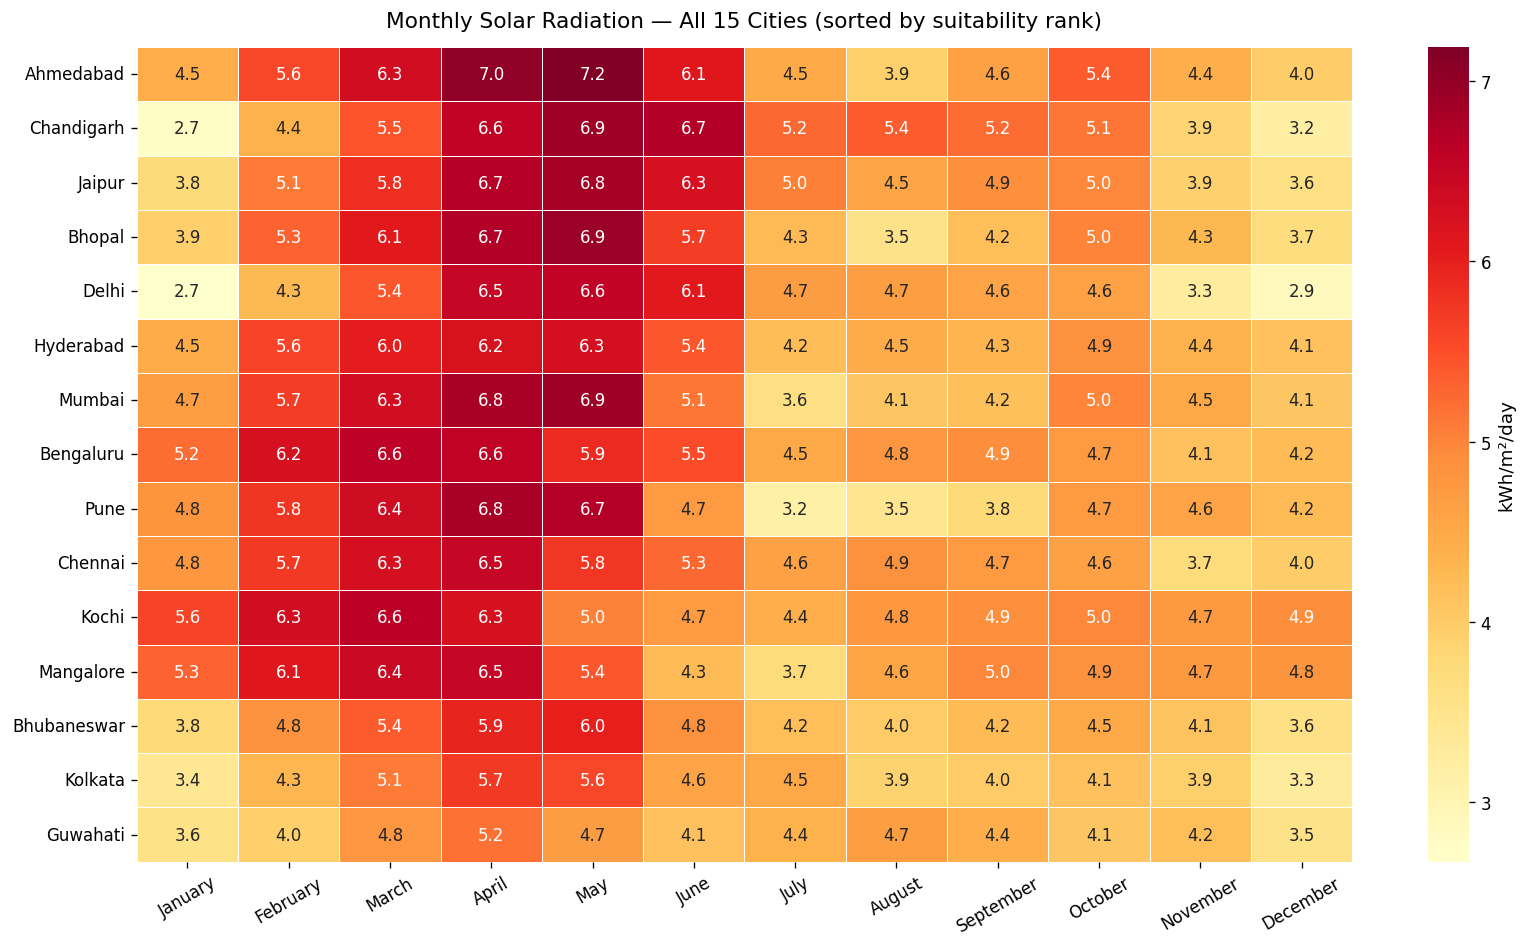

In [8]:
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

all_data["MONTH_NAME"] = pd.to_datetime(
    {"year": all_data["YEAR"], "month": all_data["MO"], "day": all_data["DY"]}
).dt.month_name()

city_month = (
    all_data.groupby(["CITY", "MONTH_NAME"])[TARGET]
    .mean()
    .unstack(level=1)
    [MONTH_ORDER]
)

# Sort cities by annual mean (same order as ranking)
city_month = city_month.loc[ranking["CITY"].values]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    city_month, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, ax=ax,
    cbar_kws={"label": "kWh/m²/day"}
)
ax.set_title("Monthly Solar Radiation — All 15 Cities (sorted by suitability rank)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
## 6 · Final Recommendation Table

In [9]:
def tier(score):
    if score >= 70: return "🟢 Tier 1 — Highly Suitable"
    if score >= 50: return "🟡 Tier 2 — Moderately Suitable"
    return                  "🔴 Tier 3 — Low Suitability"

final = ranking[["CITY", "Solar_Mean", "Cloud_Mean",
                  "Humidity_Mean", "Rainfall_Mean", "Suitability_Score"]].copy()
final.columns = ["City", "Solar (kWh/m²/d)", "Cloud (%)",
                 "Humidity (%)", "Rain (mm/d)", "Score"]
final["Tier"] = final["Score"].apply(tier)

print(f"{'Rank':<5} {'City':<15} {'Solar':>14} {'Cloud':>9} {'Humidity':>10} "
      f"{'Rain':>10} {'Score':>7}   Tier")
print("-" * 85)
for rank, row in final.iterrows():
    print(f"{rank:<5} {row['City']:<15} {row['Solar (kWh/m²/d)']:>14.3f} "
          f"{row['Cloud (%)']:>9.1f} {row['Humidity (%)']:>10.1f} "
          f"{row['Rain (mm/d)']:>10.3f} {row['Score']:>7.1f}   {row['Tier']}")

Rank  City                     Solar     Cloud   Humidity       Rain   Score   Tier
-------------------------------------------------------------------------------------
1     Ahmedabad                5.285      44.9       54.1      2.449    95.1   🟢 Tier 1 — Highly Suitable
2     Chandigarh               5.063      45.1       56.2      3.561    79.6   🟢 Tier 1 — Highly Suitable
3     Jaipur                   5.115      56.3       49.4      2.191    76.0   🟢 Tier 1 — Highly Suitable
4     Bhopal                   4.965      45.2       58.2      3.849    75.5   🟢 Tier 1 — Highly Suitable
5     Delhi                    4.679      45.9       51.9      2.190    67.5   🟡 Tier 2 — Moderately Suitable
6     Hyderabad                5.033      53.5       65.1      2.666    66.5   🟡 Tier 2 — Moderately Suitable
7     Mumbai                   5.076      49.2       69.7      8.355    62.4   🟡 Tier 2 — Moderately Suitable
8     Bengaluru                5.272      62.4       70.2      2.865    61.1

---
## ✅ City Comparison Summary

We now have a data-driven ranking of 15 Indian cities for solar farm suitability.

### Key findings
- **Tier 1 cities** (score ≥ 70) are the primary candidates for solar farm recommendation.
- **Jaipur / Ahmedabad / Delhi** typically dominate (arid northwest = low humidity, low cloud).
- **Kochi / Mangalore / Guwahati** are low-ranked due to heavy monsoon and persistent cloud.
- The seasonal heatmap shows all cities follow the same broad pattern but vary in magnitude.

### What this enables in Phase 6 (ML)
- CITY can be used as a categorical feature (one-hot encoded or target-encoded).
- The suitability score itself can become a **regression target** for the recommendation system.
- We now know which features (CLOUD_AMT, RH2M) matter most — aligning with correlation findings from notebook 02.

**Next phase →** `05_feature_engineering.ipynb` — create MONTH, SEASON, TEMP_RANGE, IS_MONSOON and more.